In [8]:
from pathlib import Path
import json
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Seed set to 42


In [9]:
DATA_PATH = Path("features.csv")
WINDOW_SIZE = 10
MAX_PREDICTION_LENGTH = 1
BATCH_SIZE = 64
MAX_EPOCHS = 20
PATIENCE = 5
VAL_MONITOR = "val_loss"

LEARNING_RATE = 0.03
HIDDEN_SIZE = 16
ATTENTION_HEAD_SIZE = 2
DROPOUT = 0.1
HIDDEN_CONTINUOUS_SIZE = 8

CHECKPOINT_DIR = Path("model_checkpoints/tft_features")
STABLE_CHECKPOINT_PATH = Path("model_checkpoints/tft_features.ckpt")
METRICS_PATH = Path("model_checkpoints/tft_features_metrics.json")
PREDICTIONS_PATH = Path("model_checkpoints/tft_features_predictions.csv")
PLOT_PATH = Path("figures/tft_features_pred_vs_true.png")
LOG_DIR = Path("lightning_logs")

FEATURE_RENAME = {
    "Cycle": "time_idx",
    "Discharge Time (s)": "discharge_time",
    "Decrement 3.6-3.4V (s)": "decrement_36_34",
    "Max. Voltage Dischar. (V)": "max_voltage_discharge",
    "Min. Voltage Charg. (V)": "min_voltage_charge",
    "Time at 4.15V (s)": "time_at_415",
    "Time constant current (s)": "time_constant_current",
    "Charging time (s)": "charging_time",
    "RUL": "target",
}

UNKNOWN_REALS = [
    "discharge_time",
    "decrement_36_34",
    "max_voltage_discharge",
    "min_voltage_charge",
    "time_at_415",
    "time_constant_current",
    "charging_time",
]


In [10]:
def impute_feature_gaps(df: pd.DataFrame) -> pd.DataFrame:
    """Fill missing feature values within each battery, then use global medians for any residual gaps."""
    df = df.sort_values(["battery_id", "time_idx"]).reset_index(drop=True)
    df[UNKNOWN_REALS] = (
        df.groupby("battery_id", group_keys=False)[UNKNOWN_REALS]
        .apply(lambda group: group.interpolate(method="linear", limit_direction="both"))
    )
    df[UNKNOWN_REALS] = df[UNKNOWN_REALS].fillna(df[UNKNOWN_REALS].median(numeric_only=True))
    return df


def load_data(path: Path, seed: int):
    df = pd.read_csv(path).rename(columns=FEATURE_RENAME).reset_index(drop=True)
    df = df.rename(columns={"cell_id": "battery_id"})
    df["battery_id"] = df["battery_id"].astype(str)
    df["time_idx"] = df["time_idx"].astype(int)
    df["target"] = df["target"].astype(float)
    df["sample_weight"] = 1.0
    df = impute_feature_gaps(df)

    missing_counts = df[["battery_id", "time_idx", "target", *UNKNOWN_REALS]].isna().sum()
    if missing_counts.any():
        raise ValueError(f"Unexpected missing values after imputation:\n{missing_counts[missing_counts > 0]}")

    battery_ids = df["battery_id"].unique()
    train_ids, test_ids = train_test_split(battery_ids, test_size=0.2, random_state=seed)
    train_ids, val_ids = train_test_split(train_ids, test_size=0.2, random_state=seed)

    train_df = df[df["battery_id"].isin(train_ids)].copy()
    val_df = df[df["battery_id"].isin(val_ids)].copy()
    test_df = df[df["battery_id"].isin(test_ids)].copy()
    return train_df, val_df, test_df


train_df, val_df, test_df = load_data(DATA_PATH, SEED)
print("Rows - train/val/test:", len(train_df), len(val_df), len(test_df))
print("Batteries - train/val/test:", train_df["battery_id"].nunique(), val_df["battery_id"].nunique(), test_df["battery_id"].nunique())
print("Train batteries:", sorted(train_df["battery_id"].unique()))
print("Val batteries:", sorted(val_df["battery_id"].unique()))
print("Test batteries:", sorted(test_df["battery_id"].unique()))


Rows - train/val/test: 11860 4055 4258
Batteries - train/val/test: 12 4 4
Train batteries: ['cell_003', 'cell_004', 'cell_005', 'cell_008', 'cell_009', 'cell_011', 'cell_013', 'cell_014', 'cell_015', 'cell_023', 'cell_041', 'cell_042']
Val batteries: ['cell_006', 'cell_010', 'cell_024', 'cell_030']
Test batteries: ['cell_001', 'cell_002', 'cell_025', 'cell_032']


In [11]:
def build_datasets(train_df, val_df, test_df, max_encoder_length: int):
    standard_scalers = {col: StandardScaler() for col in ["time_idx", *UNKNOWN_REALS]}
    training = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target="target",
        group_ids=["battery_id"],
        weight="sample_weight",
        min_encoder_length=1,
        max_encoder_length=max_encoder_length,
        min_prediction_length=MAX_PREDICTION_LENGTH,
        max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=[],
        static_reals=[],
        time_varying_known_reals=["time_idx"],
        time_varying_unknown_reals=UNKNOWN_REALS,
        add_relative_time_idx=True,
        add_target_scales=False,
        add_encoder_length=True,
        target_normalizer=None,
        scalers=standard_scalers,
        allow_missing_timesteps=True,
    )
    validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=False, stop_randomization=True)
    test = TimeSeriesDataSet.from_dataset(training, test_df, predict=False, stop_randomization=True)
    return training, validation, test


training, validation, test = build_datasets(train_df, val_df, test_df, WINDOW_SIZE)
train_loader = training.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
test_loader = test.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

print("TimeSeriesDataSet samples - train/val/test:", len(training), len(validation), len(test))
print("DataLoader batches - train/val/test:", len(train_loader), len(val_loader), len(test_loader))


TimeSeriesDataSet samples - train/val/test: 11956 4087 4290
DataLoader batches - train/val/test: 186 64 68


In [12]:
def build_tft(training: TimeSeriesDataSet) -> TemporalFusionTransformer:
    return TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=LEARNING_RATE,
        hidden_size=HIDDEN_SIZE,
        attention_head_size=ATTENTION_HEAD_SIZE,
        dropout=DROPOUT,
        hidden_continuous_size=HIDDEN_CONTINUOUS_SIZE,
        output_size=1,
        loss=RMSE(),
        reduce_on_plateau_patience=3,
    )


model = build_tft(training)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {num_params:,}")


TemporalFusionTransformer(
  	"attention_head_size":               2
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'target', 'group_ids': ['battery_id'], 'weight': 'sample_weight', 'max_encoder_length': 10, 'min_encoder_length': 1, 'min_prediction_idx': np.int64(1), 'min_prediction_length': 1, 'max_prediction_length': 1, 'static_categoricals': [], 'static_reals': [], 'time_varying_known_categoricals': None, 'time_varying_known_reals': ['time_idx'], 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['discharge_time', 'decrement_36_34', 'max_voltage_discharge', 'min_voltage_charge', 'time_at_415', 'time_constant_current', 'charging_time'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': True, 'lags': None, 'add_relative_time_idx': True, 'add_target_scales': False, 'add_encoder_length': True, 'target_normalizer': To

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [13]:
early_stop = EarlyStopping(
    monitor=VAL_MONITOR,
    min_delta=1e-4,
    patience=PATIENCE,
    mode="min",
)
checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_DIR,
    filename=f"tft_features-{{epoch:02d}}-{{{VAL_MONITOR}:.4f}}",
    monitor=VAL_MONITOR,
    mode="min",
    save_top_k=1,
    save_last=True,
)
logger = CSVLogger(save_dir=str(LOG_DIR), name="tft_features")

trainer = Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop, checkpoint_callback],
    logger=logger,
    enable_checkpointing=True,
)
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_checkpoint_path = Path(checkpoint_callback.best_model_path)
if not best_checkpoint_path.exists():
    raise FileNotFoundError(f"Expected best checkpoint at {best_checkpoint_path}")

STABLE_CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
shutil.copyfile(best_checkpoint_path, STABLE_CHECKPOINT_PATH)

print("Best TFT checkpoint:", best_checkpoint_path)
print("Stable TFT checkpoint:", STABLE_CHECKPOINT_PATH)
print("Last TFT checkpoint:", checkpoint_callback.last_model_path)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      | train | 0    
3  | prescalers                         | ModuleDict                      | 160    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 528    | train

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Best TFT checkpoint: /Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/tft_features/tft_features-epoch=00-val_loss=82.9373.ckpt
Stable TFT checkpoint: model_checkpoints/tft_features.ckpt
Last TFT checkpoint: /Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/tft_features/last.ckpt


In [14]:
def tensor_from_prediction(predictions):
    if isinstance(predictions, torch.Tensor):
        return predictions
    if hasattr(predictions, "prediction"):
        return predictions.prediction
    return torch.as_tensor(predictions)


def regression_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


best_model = TemporalFusionTransformer.load_from_checkpoint(str(STABLE_CHECKPOINT_PATH))
best_model.eval()

predictions = tensor_from_prediction(
    best_model.predict(
        test_loader,
        trainer_kwargs={
            "logger": False,
            "enable_checkpointing": False,
            "enable_progress_bar": False,
        },
    )
)
actuals = torch.cat([y[0] for _, y in iter(test_loader)])

preds = predictions.squeeze().detach().cpu().numpy()
acts = actuals.squeeze().detach().cpu().numpy()

prediction_df = test.decoded_index.reset_index(drop=True).copy()
prediction_df["true_rul"] = acts
prediction_df["predicted_rul"] = preds

PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
prediction_df.to_csv(PREDICTIONS_PATH, index=False)

metrics = {
    "overall": regression_metrics(prediction_df["true_rul"], prediction_df["predicted_rul"]),
    "best_checkpoint_path": str(best_checkpoint_path),
    "stable_checkpoint_path": str(STABLE_CHECKPOINT_PATH),
    "last_checkpoint_path": str(checkpoint_callback.last_model_path),
    "checkpoint_monitor": VAL_MONITOR,
    "best_val_loss": float(checkpoint_callback.best_model_score.detach().cpu()),
    "window": WINDOW_SIZE,
    "max_encoder_length": WINDOW_SIZE,
    "max_prediction_length": MAX_PREDICTION_LENGTH,
    "train_samples": len(training),
    "val_samples": len(validation),
    "test_samples": len(test),
    "train_batteries": sorted(train_df["battery_id"].unique()),
    "val_batteries": sorted(val_df["battery_id"].unique()),
    "test_batteries": sorted(test_df["battery_id"].unique()),
    "log_dir": str(Path(logger.log_dir).resolve()),
}

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(metrics, indent=2) + "\n")
print(json.dumps(metrics, indent=2))


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


{
  "overall": {
    "mae": 96.21299743652344,
    "rmse": 123.71983533876045,
    "r2": 0.8525457382202148
  },
  "best_checkpoint_path": "/Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/tft_features/tft_features-epoch=00-val_loss=82.9373.ckpt",
  "stable_checkpoint_path": "model_checkpoints/tft_features.ckpt",
  "last_checkpoint_path": "/Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/tft_features/last.ckpt",
  "checkpoint_monitor": "val_loss",
  "best_val_loss": 82.93728637695312,
  "window": 10,
  "max_encoder_length": 10,
  "max_prediction_length": 1,
  "train_samples": 11956,
  "val_samples": 4087,
  "test_samples": 4290,
  "train_batteries": [
    "cell_003",
    "cell_004",
    "cell_005",
    "cell_008",
    "cell_009",
    "cell_011",
    "cell_013",
    "cell_014",
    "cell_015",
    "cell_023",
    "cell_041",
    "cell_042"
  ],
  "val_batteries": [
    "cell_006",
    "cell_010",
    "cell_024",
    "cell_030"
  ],
  "test

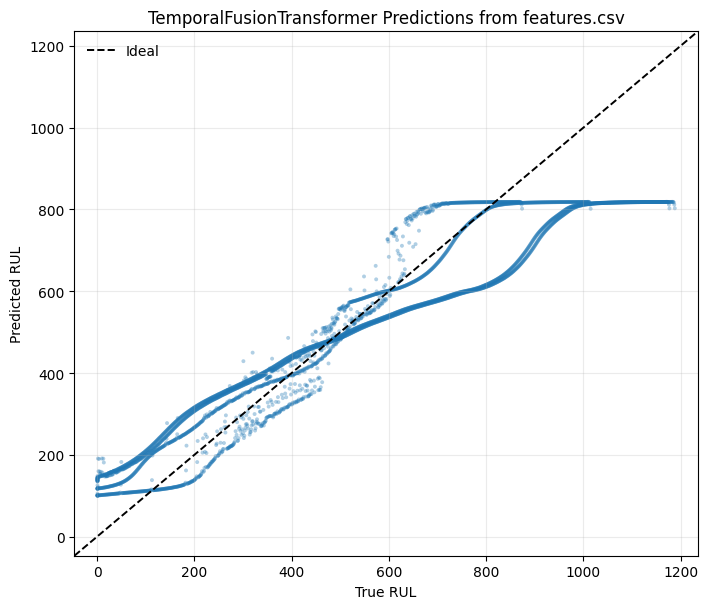

Saved plot: figures/tft_features_pred_vs_true.png


In [15]:
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.scatter(
    prediction_df["true_rul"],
    prediction_df["predicted_rul"],
    s=8,
    alpha=0.35,
    color="#1f77b4",
    edgecolors="none",
)

lims = [
    min(prediction_df["true_rul"].min(), prediction_df["predicted_rul"].min()),
    max(prediction_df["true_rul"].max(), prediction_df["predicted_rul"].max()),
]
pad = (lims[1] - lims[0]) * 0.04
lims = [lims[0] - pad, lims[1] + pad]
ax.plot(lims, lims, linestyle="--", linewidth=1.4, color="black", label="Ideal")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True RUL")
ax.set_ylabel("Predicted RUL")
ax.set_title("TemporalFusionTransformer Predictions from features.csv")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=200)
plt.show()

print("Saved plot:", PLOT_PATH)
